setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (10, 5)

nacitavanie dát

In [2]:
readings = pd.read_csv("dataset/readings.csv", sep="\t")
units    = pd.read_csv("dataset/units.csv",    sep=",")
gateways = pd.read_csv("dataset/gateways.csv", sep=";")

for name, df in [("readings", readings), ("units", units), ("gateways", gateways)]:
    print(f"\n===== {name}: {df.shape[0]} riadkov x {df.shape[1]} atribútov =====")
    display(df.head(3))
    print(df.dtypes)


===== readings: 15054 riadkov x 10 atribútov =====


,unit_id,ts_cycle,motor_current,dpFilter,temperature_oil,reservoir_pressure,rms_vibration,flowmeter,temp_bearing,Failure
0,U01674,2023/12/23,6.27884,32.40811,37.34988,7.92246,4.08952,22.94033,65.31510,0
1,U01901,19 Jul 2023,5.43371,19.37059,64.77418,7.49991,5.63354,22.77973,76.16687,0
2,U01840,2023/06/22,3.32302,19.89546,39.05909,8.19003,4.72607,28.59536,62.76578,0


unit_id                   str
ts_cycle                  str
motor_current         float64
dpFilter              float64
temperature_oil       float64
reservoir_pressure    float64
rms_vibration         float64
flowmeter             float64
temp_bearing          float64
Failure                 int64
dtype: object

===== units: 2000 riadkov x 8 atribútov =====


,unit_id,installRegion,lineCode,commission_year,id_depot,class_duty,operatorOwner,hoursService
0,1,München,L4,2021,21,light,Linke,11777.6
1,2,Davidsonland,L1,2020,96,3,Nguyen Group,14096.9
2,3,Évora,L4,2023,17,light,Antunes e Filhos,5694.4


unit_id              int64
installRegion          str
lineCode               str
commission_year      int64
id_depot             int64
class_duty             str
operatorOwner          str
hoursService       float64
dtype: object

===== gateways: 16000 riadkov x 14 atribútov =====


,lastSeen,install_date,Technician,hardwareModel,Lat,signalDbm,vendor,Ipv4,unit_id,gateway_id,address_mac,id_depot,lon,version_firmware
0,2024-08-12,21 Mar 2020,Ana Pinho,NODE-7,41.51270,-65.8,Cruz,85.128.19.204,48.0,GW-00000,49:f4:4d:79:81:8b,104,-7.04227,v1.2.5
1,"04/19/2024, 00:00:00",22 Mar 2019,Rodney Davis,GWX-200,40.66560,-62.5,Butte AG,161.204.105.137,1536.0,GW-00001,80:1b:32:8c:b1:38,107,-6.98997,v1.2.5
2,2024-11-13,2023/04/12,Michael Morales,NODE-9,38.87221,-65.0,Butte AG,18.11.139.72,1093.0,GW-00002,3b:ed:c2:34:a2:47,113,-6.79899,v1.2.5


lastSeen                str
install_date            str
Technician              str
hardwareModel           str
Lat                 float64
signalDbm           float64
vendor                  str
Ipv4                    str
unit_id             float64
gateway_id              str
address_mac             str
id_depot              int64
lon                 float64
version_firmware        str
dtype: object


In [3]:
for name, df in [("readings", readings), ("units", units), ("gateways", gateways)]:
    print(f"\n--- {name} chýbajúce hodnoty ---")
    print(df.isna().sum())


--- readings chýbajúce hodnoty ---
unit_id                 0
ts_cycle                0
motor_current           0
dpFilter              586
temperature_oil         0
reservoir_pressure      0
rms_vibration         633
flowmeter               0
temp_bearing            0
Failure                 0
dtype: int64

--- units chýbajúce hodnoty ---
unit_id              0
installRegion        0
lineCode             0
commission_year      0
id_depot             0
class_duty           0
operatorOwner        0
hoursService       100
dtype: int64

--- gateways chýbajúce hodnoty ---
lastSeen                0
install_date            0
Technician              0
hardwareModel           0
Lat                     0
signalDbm               0
vendor                  0
Ipv4                    0
unit_id             14000
gateway_id              0
address_mac             0
id_depot                0
lon                     0
version_firmware        0
dtype: int64


## Fáza 1 — Prieskumná analýza
### 1.1 Základný opis dát spolu s ich charakteristikami

Cieľová premenná je **`Failure`** (0/1) v súbore `readings`. Dáta sú rozdelené do troch súborov: `readings` (jeden záznam na jednotku a cyklus), `units` (jeden záznam na jednotku), `gateways` (jeden záznam na bránu/gateway).

#### Príprava: zjednotenie kľúča `unit_id` a pripojenie metadát jednotiek
V `readings` je `unit_id` v tvare `U01674` (reťazec), v `units` je to celé číslo a v `gateways` desatinné číslo. Aby sme mohli súbory spojiť, kľúč najprv zjednotíme na číslo. Výsledok potrebujeme pre bod (B) — bez metadát máme len 8 senzorov — a je priamou odpoveďou na otázku z bodu (E), či treba kombinovať súbory.

In [4]:
# zjednotenie kľúča unit_id naprieč súbormi
readings["unit_num"] = readings["unit_id"].str.extract(r"(\d+)").astype("Int64")
units["unit_num"]    = units["unit_id"].astype("Int64")

# ľahký left-join metadát jednotiek do meraní (granularita ostáva = readings)
df = readings.merge(units, on="unit_num", how="left", suffixes=("", "_unit"))

match_rate = df["installRegion"].notna().mean()
print(f"Podiel meraní napárovaných na jednotku: {match_rate:.1%}")
print("Počet nenapárovaných jednotiek:", df.loc[df['installRegion'].isna(), 'unit_num'].nunique())
print("Tvar spojeného datasetu:", df.shape)

Podiel meraní napárovaných na jednotku: 99.1%
Počet nenapárovaných jednotiek: 125
Tvar spojeného datasetu: (15054, 19)


#### (A) Analýza štruktúry súborov a záznamov
Pre každý súbor uvádzame počet záznamov, počet atribútov, dátové typy a ukážku záznamov. Vzťahy: `readings` ↔ `units` cez `unit_id`, `gateways` ↔ `units` cez `unit_id` / `id_depot`.

In [5]:
for name, d in [("readings", readings), ("units", units), ("gateways", gateways)]:
    print(f"\n===== {name}: {d.shape[0]} záznamov x {d.shape[1]} atribútov =====")
    display(d.dtypes.to_frame("dtype"))
    display(d.head(3))

# vzťahy medzi súbormi cez kľúče
print("unikátne unit_id – readings:", readings['unit_num'].nunique())
print("unikátne unit_id – units:   ", units['unit_num'].nunique())
print("unikátne unit_id – gateways:", gateways['unit_id'].nunique())


===== readings: 15054 záznamov x 11 atribútov =====


,dtype
unit_id,str
ts_cycle,str
motor_current,float64
dpFilter,float64
temperature_oil,float64
reservoir_pressure,float64
rms_vibration,float64
flowmeter,float64
temp_bearing,float64
Failure,int64


,unit_id,ts_cycle,motor_current,dpFilter,temperature_oil,reservoir_pressure,rms_vibration,flowmeter,temp_bearing,Failure,unit_num
0,U01674,2023/12/23,6.27884,32.40811,37.34988,7.92246,4.08952,22.94033,65.31510,0,1674
1,U01901,19 Jul 2023,5.43371,19.37059,64.77418,7.49991,5.63354,22.77973,76.16687,0,1901
2,U01840,2023/06/22,3.32302,19.89546,39.05909,8.19003,4.72607,28.59536,62.76578,0,1840



===== units: 2000 záznamov x 9 atribútov =====


,dtype
unit_id,int64
installRegion,str
lineCode,str
commission_year,int64
id_depot,int64
class_duty,str
operatorOwner,str
hoursService,float64
unit_num,Int64


,unit_id,installRegion,lineCode,commission_year,id_depot,class_duty,operatorOwner,hoursService,unit_num
0,1,München,L4,2021,21,light,Linke,11777.6,1
1,2,Davidsonland,L1,2020,96,3,Nguyen Group,14096.9,2
2,3,Évora,L4,2023,17,light,Antunes e Filhos,5694.4,3



===== gateways: 16000 záznamov x 14 atribútov =====


,dtype
lastSeen,str
install_date,str
Technician,str
hardwareModel,str
Lat,float64
signalDbm,float64
vendor,str
Ipv4,str
unit_id,float64
gateway_id,str


,lastSeen,install_date,Technician,hardwareModel,Lat,signalDbm,vendor,Ipv4,unit_id,gateway_id,address_mac,id_depot,lon,version_firmware
0,2024-08-12,21 Mar 2020,Ana Pinho,NODE-7,41.51270,-65.8,Cruz,85.128.19.204,48.0,GW-00000,49:f4:4d:79:81:8b,104,-7.04227,v1.2.5
1,"04/19/2024, 00:00:00",22 Mar 2019,Rodney Davis,GWX-200,40.66560,-62.5,Butte AG,161.204.105.137,1536.0,GW-00001,80:1b:32:8c:b1:38,107,-6.98997,v1.2.5
2,2024-11-13,2023/04/12,Michael Morales,NODE-9,38.87221,-65.0,Butte AG,18.11.139.72,1093.0,GW-00002,3b:ed:c2:34:a2:47,113,-6.79899,v1.2.5


unikátne unit_id – readings: 2124
unikátne unit_id – units:    2000
unikátne unit_id – gateways: 2000


#### (B) Analýza jednotlivých atribútov
Analyzujeme atribúty z `readings` a vybrané metadáta z `units` (`hoursService`, `commission_year`)

Sledujeme distribúcie, deskriptívne štatistiky a či hodnoty spadajú do fyzikálne zmysluplného rozsahu.

,count,mean,std,min,25%,50%,75%,max
motor_current,15054.0,5.379622,3.387158,0.18049,3.823803,5.232670,6.694905,99.00000
dpFilter,14468.0,24.062098,11.225899,6.72633,16.328775,21.330750,28.824825,120.00000
temperature_oil,15054.0,51.983696,57.517512,-999.00000,46.876445,54.933285,62.956630,95.00000
reservoir_pressure,15054.0,8.697440,0.597343,6.52355,8.297107,8.704205,9.099225,10.50000
rms_vibration,14421.0,3.072144,1.628190,0.50000,1.937770,2.701700,3.798090,14.00000
flowmeter,15054.0,28.048406,3.990746,15.00000,25.333645,28.047195,30.748483,40.00000
temp_bearing,15054.0,65.022996,8.083955,31.24129,59.637955,64.997320,70.442180,95.85774
hoursService,14154.0,14481.970616,8777.903314,1605.70000,8134.200000,12361.000000,18354.400000,45000.00000
commission_year,14913.0,2020.393817,2.530025,2012.00000,2019.000000,2021.000000,2022.000000,2024.00000


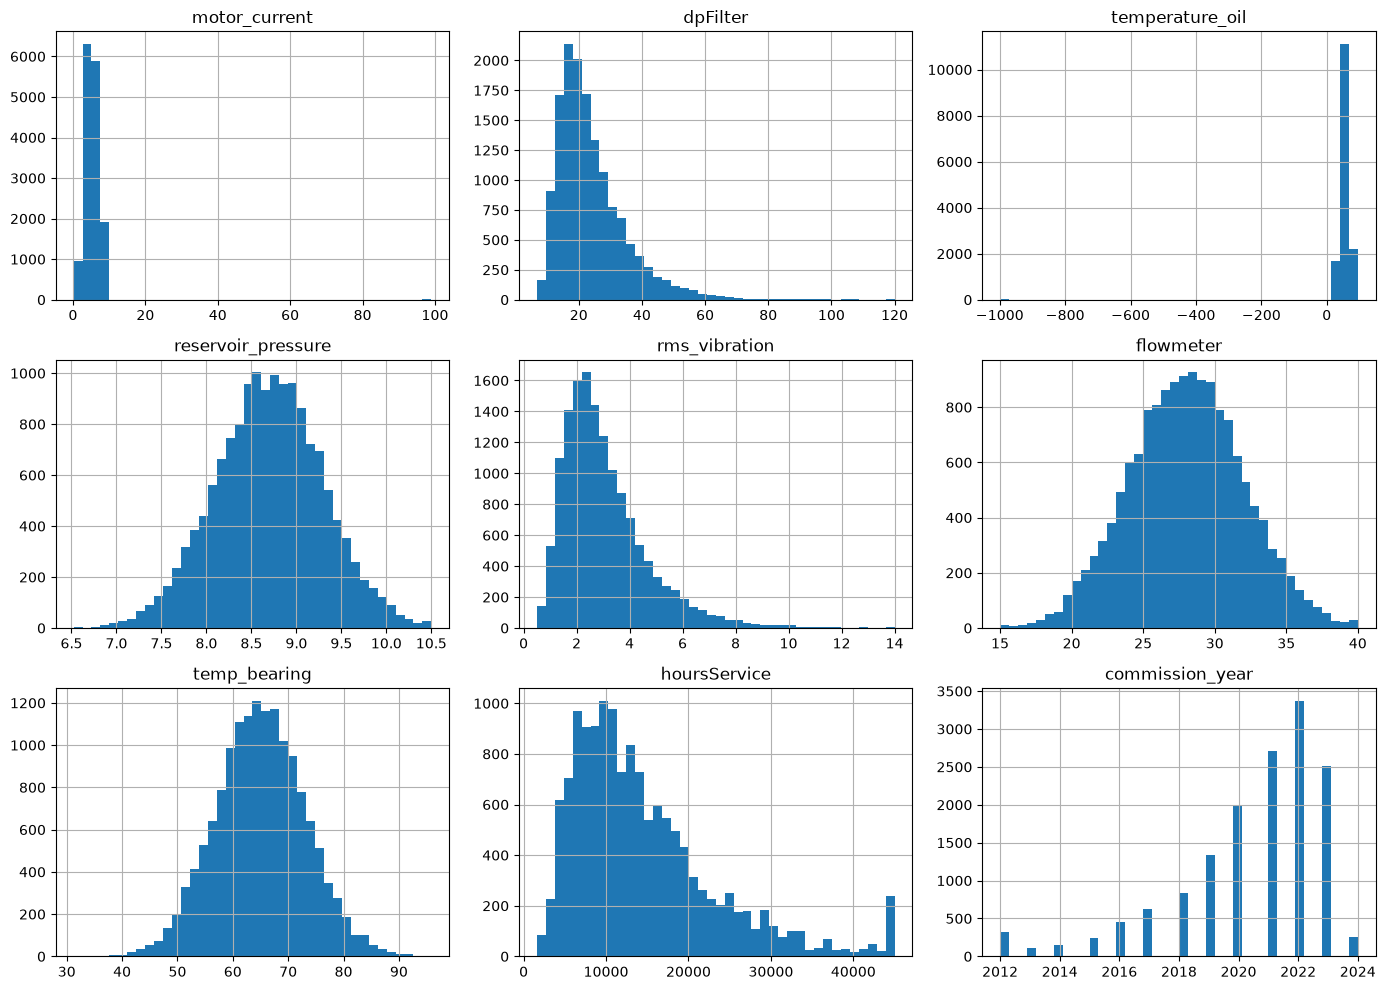

Kontrola rozsahu senzorov:
motor_current        min=    0.18  max=   99.00  zápor: 0
dpFilter             min=    6.73  max=  120.00  zápor: 0
temperature_oil      min= -999.00  max=   95.00  zápor: 43
reservoir_pressure   min=    6.52  max=   10.50  zápor: 0
rms_vibration        min=    0.50  max=   14.00  zápor: 0
flowmeter            min=   15.00  max=   40.00  zápor: 0
temp_bearing         min=   31.24  max=   95.86  zápor: 0


In [ ]:
sensors = ["motor_current", "dpFilter", "temperature_oil", "reservoir_pressure", "rms_vibration", "flowmeter", "temp_bearing"]
extra   = ["hoursService", "commission_year"]
num_cols = sensors + extra

# deskriptívne štatistiky
display(df[num_cols].describe().T)

# distribúcie
df[num_cols].hist(bins=40, figsize=(14, 10))
plt.tight_layout(); plt.show()

# kontrola rozsahu meraných hodnôt (napr. záporné hodnoty, ktoré by nemali nastať)
print("Kontrola rozsahu senzorov:")
for c in sensors:
    print(f"{c:20s} min={df[c].min():8.2f}  max={df[c].max():8.2f}  zápor: {(df[c] < 0).sum()}")

In [ ]:
# ukážka kategorických atribútov
for c in ["class_duty", "lineCode", "installRegion"]:
    print(f"\n{c}:")
    print(df[c].value_counts(dropna=False).head(8))


class_duty:
class_duty
1        1709
L        1695
light    1658
2        1310
H        1296
N        1288
med      1261
heavy    1241
Name: count, dtype: int64

lineCode:
lineCode
L6     2734
L5     2572
L3     2556
L4     2471
L2     2290
L1     2290
NaN     141
Name: count, dtype: int64

installRegion:
installRegion
Évora                         534
München                       518
Mêda                          323
Fundão                        317
Almeirim                      308
Reguengos de Monsaraz         307
Vila Real de Santo António    306
Barcelos                      298
Name: count, dtype: int64


#### (C) Párová analýza — vzťahy medzi atribútmi
Korelačná matica odhalí navzájom závislé (potenciálne redundantné) atribúty.

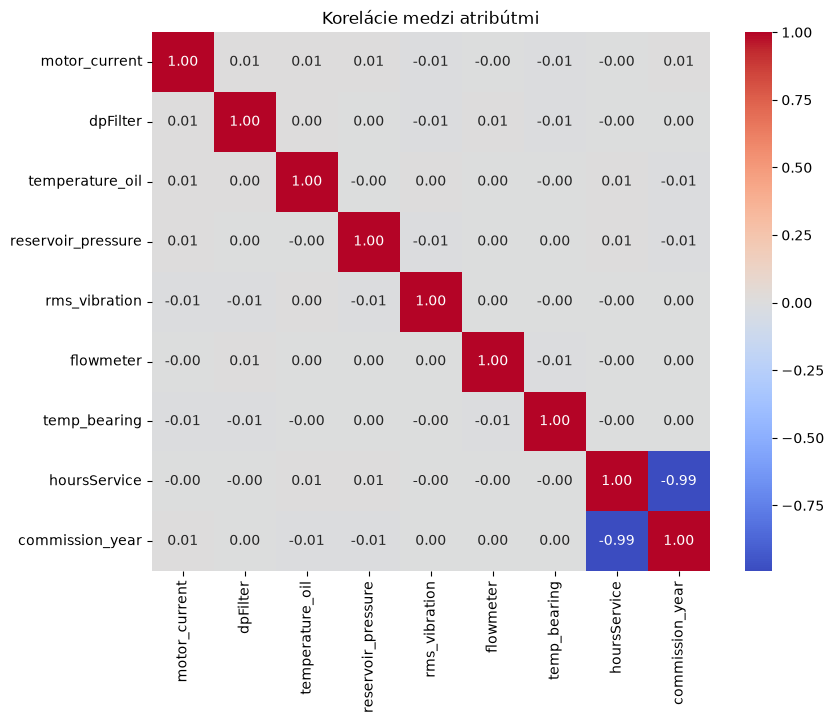

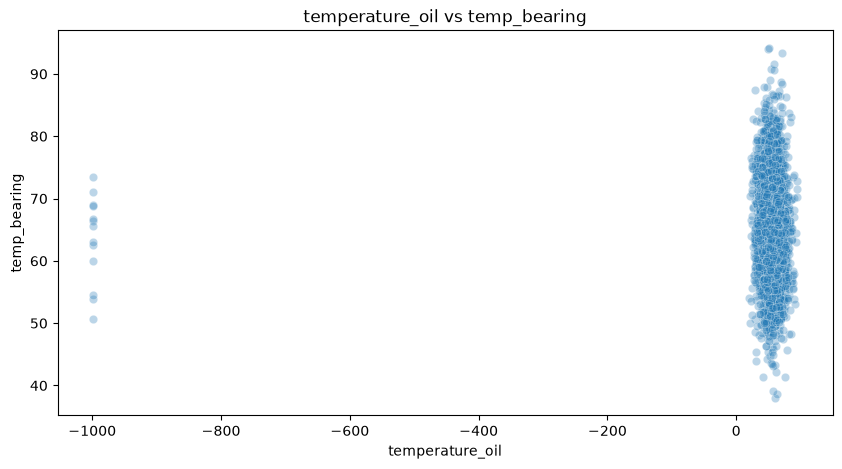

In [8]:
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korelácie medzi atribútmi"); plt.show()

# detailný pohľad na jeden pár
sns.scatterplot(data=df.sample(min(3000, len(df)), random_state=0),
                x="temperature_oil", y="temp_bearing", alpha=0.3)
plt.title("temperature_oil vs temp_bearing"); plt.show()

#### (D) Párová analýza — vzťah medzi `Failure` a prediktormi
Hľadáme senzory, ktoré najlepšie oddeľujú stav poruchy od normálu.

Rozloženie cieľovej premennej Failure:
Failure
0    0.882
1    0.118
Name: proportion, dtype: float64


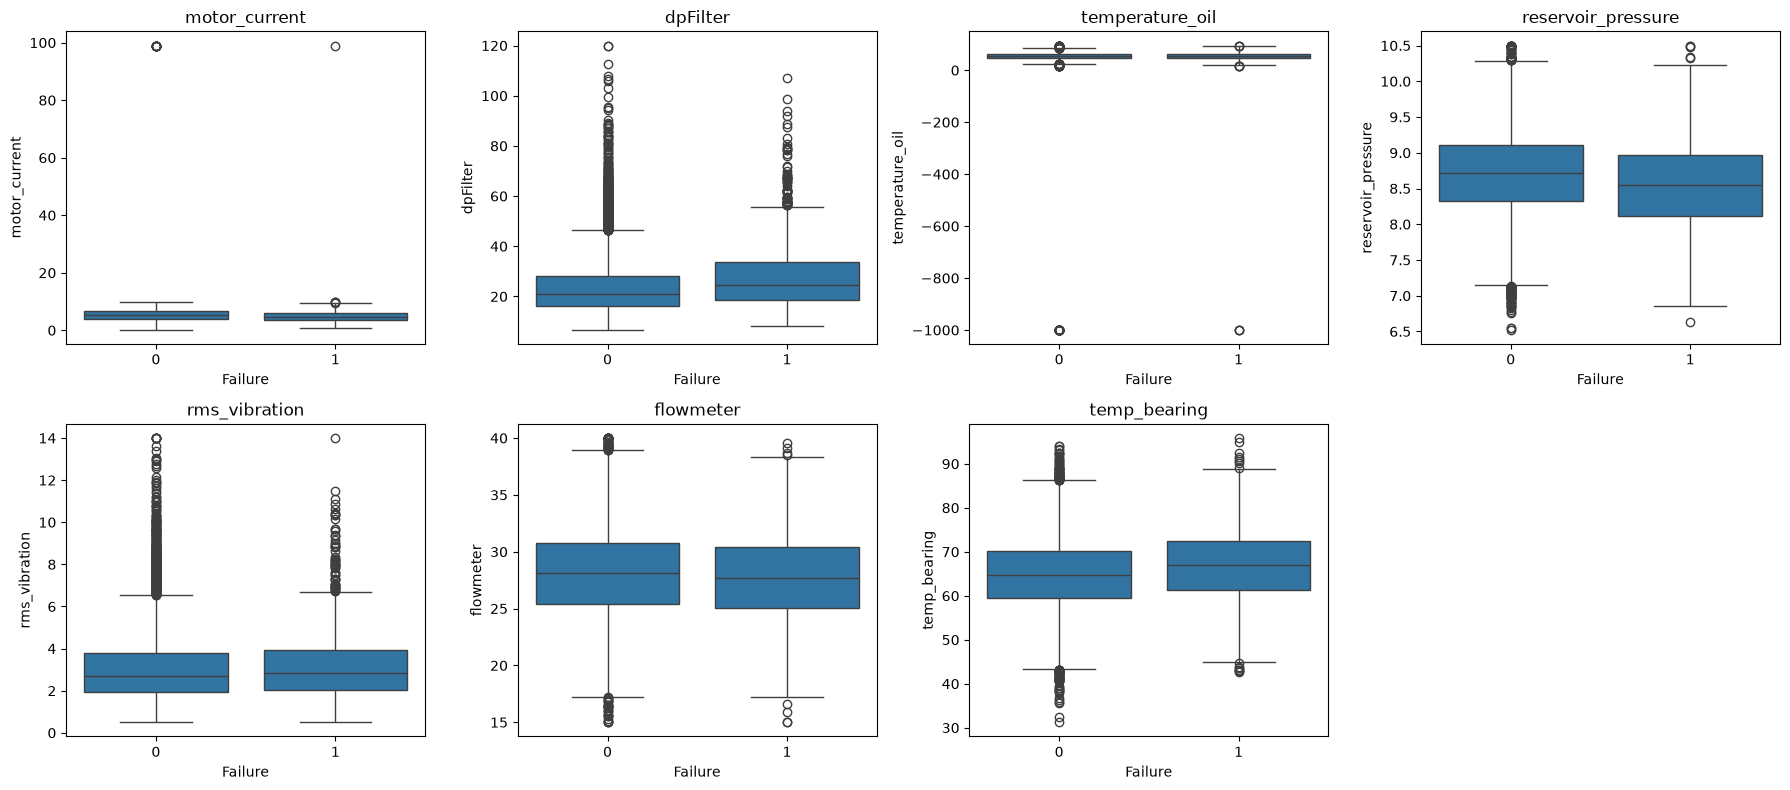

In [9]:
print("Rozloženie cieľovej premennej Failure:")
print(df["Failure"].value_counts(normalize=True).round(3))

# rozdelenie senzorov podľa stavu failure
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, c in zip(axes.ravel(), sensors):
    sns.boxplot(data=df, x="Failure", y=c, ax=ax)
    ax.set_title(c)
fig.delaxes(axes.ravel()[-1])  # 7 senzorov, 8 pozícií
plt.tight_layout(); plt.show()

In [10]:
# priemery v oboch triedach a relatívny rozdiel
means = df.groupby("Failure")[sensors].mean().T
means["rozdiel_%"] = (means[1] - means[0]) / means[0] * 100
display(means.sort_values("rozdiel_%", key=abs, ascending=False))

# korelácia každého senzora s cieľom
display(df[sensors + ["Failure"]].corr()["Failure"].drop("Failure")
        .sort_values(key=abs, ascending=False).to_frame("korelácia s Failure"))

Failure,0,1,rozdiel_%
dpFilter,23.627475,27.952186,18.303739
motor_current,5.427571,5.021360,-7.484218
rms_vibration,3.057474,3.206773,4.883102
temp_bearing,64.772141,66.897283,3.280951
temperature_oil,51.786524,53.456880,3.225466
reservoir_pressure,8.716447,8.555427,-1.847314
flowmeter,28.090065,27.737147,-1.256379


,korelácia s Failure
dpFilter,0.115832
reservoir_pressure,-0.086979
temp_bearing,0.084824
motor_current,-0.038697
flowmeter,-0.028535
rms_vibration,0.027296
temperature_oil,0.009371


#### (E) Prvotné zamyslenie k riešeniu

**Sú niektoré atribúty medzi sebou závislé?** Áno — z korelačnej matice (bod C) vidno dvojice senzorov s vyššou koreláciou, čo naznačuje možnú redundanciu, ktorú zohľadníme pri výbere atribútov vo fáze 2/3. _(doplňte konkrétne dvojice podľa výsledku heatmapy)_

**Od ktorých atribútov závisí predikovaná premenná?** Podľa bodu D najviac oddeľujú triedy senzory s najväčším relatívnym rozdielom priemerov a najvyššou koreláciou s `Failure`. _(doplňte konkrétne senzory podľa tabuliek z bodu D)_ — tie sú kandidátmi na hlavné prediktory a základ hypotéz v 1.3.

**Treba kombinovať záznamy z viacerých súborov?** Áno. Senzory aj cieľ sú v `readings`, ale bohatšie prediktory (`hoursService`, `class_duty`, `commission_year`, `installRegion`) sú v `units`; kontext siete je v `gateways`. Spojenie funguje veľmi dobre — napáruje sa ~99 % meraní (viď prípravný krok), pričom kľúč `unit_id` bolo treba najprv zjednotiť (`U01674` → `1674`). `readings` obsahuje viac jednotiek než `units`, takže časť záznamov sa nenapáruje. Zapojenie `gateways` (iná granularita, `unit_id` chýba v 14 000 riadkoch) zvážime samostatne.